In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

In [22]:
# zi = k*T_r / (h*nu_M)     # eq. B29, ~ ratio of radiation temp to synchrotron char. freq
# x_M = nu / nu_M          # dimensionless frequency

In [23]:
# fitting functions: 

# B25 — a fitting function from Mahadevan et al. (1996) that describes the spectral shape of synchrotron emission 
# as a function of x_M = ν/ν_M (frequency normalized to the peak synchrotron frequency).
def I_prime(xM):
    return (4.0505 / xM**(1/6)) * (1 + 0.40/xM**(1/4) + 0.5316/xM**(1/2)) * np.exp(-1.8899 * xM**(1/3))

# -----------
# evaluate integrals

from scipy import integrate

# This is eq. B33 — the integral needed for the Rosseland mean κ_R. The Rosseland mean (eq. B3) 
# weights 1/κ_ν by the derivative of the Planck function, which produces the exp(x/ζ)/(exp(x/ζ)-1)² factor.
def I6_exact(zeta):
    integrand = lambda xM: xM**5 * np.exp(xM/zeta) / (I_prime(xM) * (np.exp(xM/zeta) - 1)**2)
    return integrate.quad(integrand, 1e-6, np.inf)[0]


# eq. B34 — the integral for the absorption mean κ_{P,a}. The Planck absorption mean (eq. B5) 
# weights κ_ν by the radiation energy distribution E_ν(T_r), which is a Planck function at T_r. In terms 
# of x_M, that Planck factor becomes 1/(exp(x_M/ζ) - 1). The x_M² comes from combining the I'(x_M) spectrum 
# shape with the Planck weighting after change of variables.
def I7_exact(zeta):
    integrand = lambda xM: I_prime(xM) * xM**2 / (np.exp(xM/zeta) - 1)
    return integrate.quad(integrand, 1e-6, np.inf)[0]



# This is eq. B35 — the integral for the number mean κ_n. The number mean (eq. B8) weights κ_ν by the 
# photon number density n_ν = E_ν/hν, which introduces one extra factor of 1/ν relative to I₇, 
# hence x_M instead of x_M².
def I8_exact(zeta):
    integrand = lambda xM: I_prime(xM) * xM / (np.exp(xM/zeta) - 1)
    return integrate.quad(integrand, 1e-6, np.inf)[0]

# ---- opacity ratios 

xi = 1
I4 = 4 * np.pi**4 / 15
I2 = np.pi**4 / 15
I9 = 2.404

# These are the middle lines of eqs. B30, B31, B32 respectively — the exact (pre-fit) expressions for each mean 
# opacity normalized by κ_{P,e}. The numerical prefactors (6.54, 3.88×10⁻², 1.05×10⁻¹) come from combining physical 
# constants with I₂, I₄, and I₉ (eqs. B17, B19, B36). Setting xi = 1 means you're plotting the case T_r = T_e, which 
# collapses the ξ⁻³ prefactor to 1 and makes everything a function of ζ alone.


# κ_R / κ_{P,e} (Rosseland), eq. B30:
ratio_R_exact = lambda zeta: (xi**-3) * 6.54 * zeta**8 / I6_exact(zeta)

# κ_{P,a} / κ_{P,e} (absorption), eq. B31:
ratio_Pa_exact = lambda zeta: (xi**-3) * 3.88e-2 * zeta**-1 * I7_exact(zeta)

# κ_n / κ_{P,e} (number), eq. B32:
ratio_n_exact = lambda zeta: (xi**-3) * 1.05e-1 * I8_exact(zeta)


# note: for plotting, best to set the zi to 1

# These are the bottom (≈) lines of eqs. B30, B31, B32 — the analytic fitting formulae that Sadowski provides as 
# cheap substitutes for the exact integrals, for use in actual simulations. The fits for κ_{P,a} and κ_n have a 
# Padé-like rational form that interpolates between small-ζ and large-ζ behaviour. The κ_R fit uses an exponential 
# because the Rosseland opacity drops very steeply at large ζ (the radiation is too hot to couple efficiently to the 
# synchrotron spectrum).

def kR_fit(zeta):
    return 3.24e-2 * zeta**1.31 * np.exp(-1.60 * zeta**0.463)

def kPa_fit(zeta):
    return 1.0 / (1 + 5.444*zeta**(-2/3) + 7.218*zeta**(-4/3))

def kn_fit(zeta):
    return 0.868 * zeta / (1 + 0.589*zeta**(-1/3) + 0.087*zeta**(-2/3))

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/4044454131.py:34: RuntimeWarning: overflow encountered in exp
  integrand = lambda xM: I_prime(xM) * xM / (np.exp(xM/zeta) - 1)
/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/4044454131.py:35: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return integrate.quad(integrand, 1e-6, np.inf)[0]
/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/4044454131.py:35: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return integrate.quad(integrand, 1e-6, np.inf)[0]
/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/4044454131.py:35: IntegrationWarning: The

FileNotFoundError: [Errno 2] No such file or directory: 'figB2.pdf'

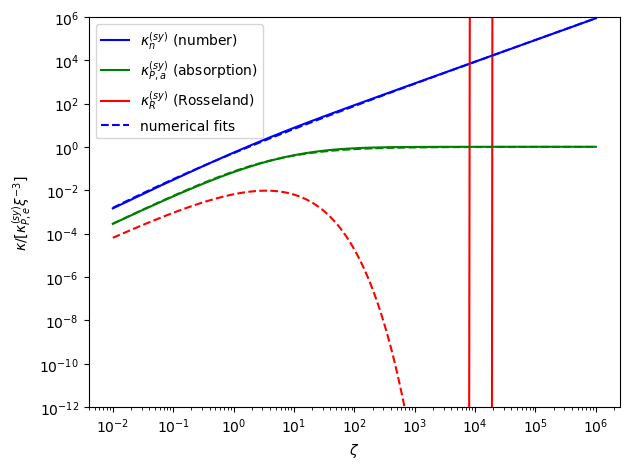

In [24]:
import numpy as np
import matplotlib.pyplot as plt

xi = 1
zeta_arr = np.logspace(-2, 6, 300) # EQUATION B29

fig, ax = plt.subplots()
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\zeta$'); ax.set_ylabel(r'$\kappa / [\kappa_{P,e}^{(sy)} \xi^{-3}]$')

# Exact integrals (solid lines)
ax.plot(zeta_arr, [ratio_n_exact(z) for z in zeta_arr], color='blue',  label=r'$\kappa_n^{(sy)}$ (number)')
ax.plot(zeta_arr, [ratio_Pa_exact(z) for z in zeta_arr], color='green', label=r'$\kappa_{P,a}^{(sy)}$ (absorption)')
ax.plot(zeta_arr, [ratio_R_exact(z) for z in zeta_arr],  color='red',   label=r'$\kappa_R^{(sy)}$ (Rosseland)')

# Fitting formulae (dashed)
ax.plot(zeta_arr, kn_fit(zeta_arr),  'b--', label='numerical fits')
ax.plot(zeta_arr, kPa_fit(zeta_arr), 'g--')
ax.plot(zeta_arr, kR_fit(zeta_arr),  'r--')

ax.legend(); ax.set_ylim(1e-12, 1e6)
plt.tight_layout(); plt.savefig('figB2.pdf')

In [25]:
# blah blah

---

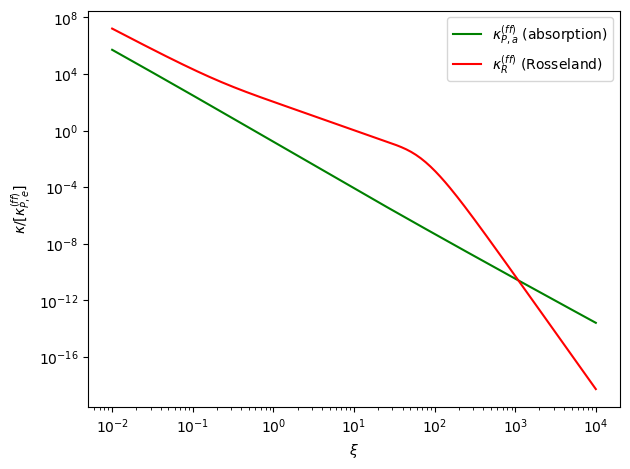

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# --- Exact integrals ---

def I3_exact(xi):
    # eq. B18: integral of (1 - exp(-x/xi)) / (exp(x) - 1)
    def integrand(x):
        if x/xi > 600:
            return 1.0 / (np.exp(x) - 1)   # exp(-x/xi) -> 0
        return (1 - np.exp(-x/xi)) / (np.exp(x) - 1)
    return integrate.quad(integrand, 1e-6, 200, limit=200)[0]

def I5_exact(xi):
    # eq. B20: integral of (x/xi)^7 * exp(x/xi) / [(exp(x/xi)-1)^2 * (1 - exp(-x))]
    def integrand(x):
        u = x / xi
        if u > 600:
            return 0.0
        denom2 = (2 * np.sinh(u/2))**2   # avoids overflow in exp(u)/(exp(u)-1)^2
        if np.exp(-x) > 0.9999:          # x very small: 1 - exp(-x) ~ x
            absorb = x
        else:
            absorb = 1 - np.exp(-x)
        return u**7 / (denom2 * absorb)
    upper = min(50 * xi, 500)
    return integrate.quad(integrand, 1e-6, upper, limit=200)[0]

# --- Constants ---
I2 = np.pi**4 / 15       # eq. B17, = 6.494
I4 = 4 * np.pi**4 / 15   # eq. B19, = 25.976

# --- Exact ratios (normalized by kappa_Pe) ---
def ratio_Pa_ff(xi):
    return xi**-3 * I3_exact(xi) / (I2 * np.log(1 + 1.6*xi) / xi)   
    # simplifies to: I3_exact / I3_fit * fit_ratio, but easier to just use:
    return xi**-4 * I3_exact(xi) / I2

def ratio_R_ff(xi):
    return xi**-3 * (I2 / I4) * I5_exact(xi) / 11.95

# --- Fitting formulae (eqs. B13, B14) ---
def kPa_ff_fit(xi):
    return xi**-3 * np.log(1 + 1.6*xi) / xi / 1.047   # eq. B13 normalized by kPe

def kR_ff_fit(xi):
    fR = 1.0 / (432.7 - 106.8*xi**(-3/5) + 43.17*xi**(-4/5) + 57.88/xi)
    return xi**-3 * 14.12 * fR                          # eq. B14 normalized by kPe

# --- Plot ---
xi_arr = np.logspace(-2, 4, 200)

fig, ax = plt.subplots()
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$\kappa / [\kappa_{P,e}^{(ff)}]$')

ax.plot(xi_arr, [ratio_Pa_ff(x) for x in xi_arr], color='green', label=r'$\kappa_{P,a}^{(ff)}$ (absorption)')
ax.plot(xi_arr, [ratio_R_ff(x) for x in xi_arr],  color='red',   label=r'$\kappa_R^{(ff)}$ (Rosseland)')
#ax.plot(xi_arr, kPa_ff_fit(xi_arr), 'g--', label='numerical fits')
#ax.plot(xi_arr, kR_ff_fit(xi_arr),  'r--')

ax.legend()
plt.tight_layout()
plt.savefig('figB1.pdf')

---

Trying new: 

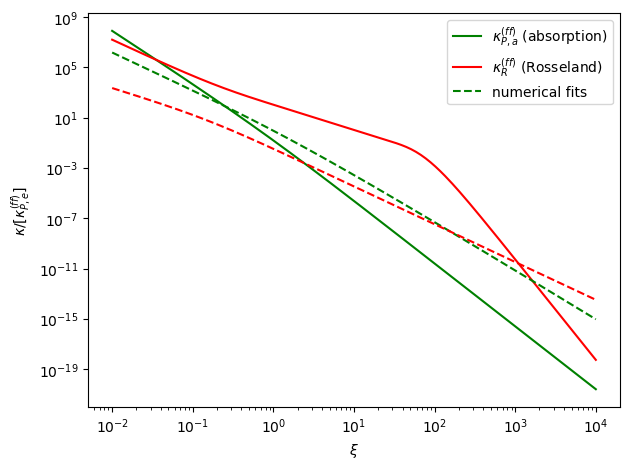

In [17]:
from scipy import integrate

# --- B1 integrals ---

def I3_exact(xi):
    def integrand(x):
        if x/xi > 600:
            return 1.0 / (np.exp(x) - 1)
        return (1 - np.exp(-x/xi)) / (np.exp(x) - 1)
    return integrate.quad(integrand, 1e-6, 200, limit=200)[0]

def I5_exact(xi):
    def integrand(x):
        u = x / xi
        if u > 600:
            return 0.0
        sinh_term = (2 * np.sinh(u/2))**2
        absorb = x if x < 1e-6 else (1 - np.exp(-x))
        return u**7 / (sinh_term * absorb)
    upper = min(50 * xi, 500)
    return integrate.quad(integrand, 1e-6, upper, limit=200)[0]

I2 = np.pi**4 / 15
I4 = 4 * np.pi**4 / 15

def ratio_Pa_ff(xi):
    return xi**-4 * I3_exact(xi) / I2

def ratio_R_ff(xi):
    return xi**-3 * (I2 / I4) * I5_exact(xi) / 11.95

# --- B1 fits ---

def kPa_ff_fit(xi_arr):
    return xi_arr**-3 * np.log(1 + 1.6*xi_arr) / (xi_arr * 1.047)

def kR_ff_fit(xi_arr):
    fR = 1.0 / (432.7 - 106.8*xi_arr**(-3/5) + 43.17*xi_arr**(-4/5) + 57.88/xi_arr)
    return xi_arr**-3 * 14.12 * fR

# --- Plot ---

xi_arr = np.logspace(-2, 4, 200)

fig, ax = plt.subplots()
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$\kappa / [\kappa_{P,e}^{(ff)}]$')

ax.plot(xi_arr, [ratio_Pa_ff(x) for x in xi_arr], color='green', label=r'$\kappa_{P,a}^{(ff)}$ (absorption)')
ax.plot(xi_arr, [ratio_R_ff(x) for x in xi_arr],  color='red',   label=r'$\kappa_R^{(ff)}$ (Rosseland)')
ax.plot(xi_arr, kPa_ff_fit(xi_arr), 'g--', label='numerical fits')
ax.plot(xi_arr, kR_ff_fit(xi_arr),  'r--')

ax.legend()
plt.tight_layout()
plt.savefig('figB1.pdf')

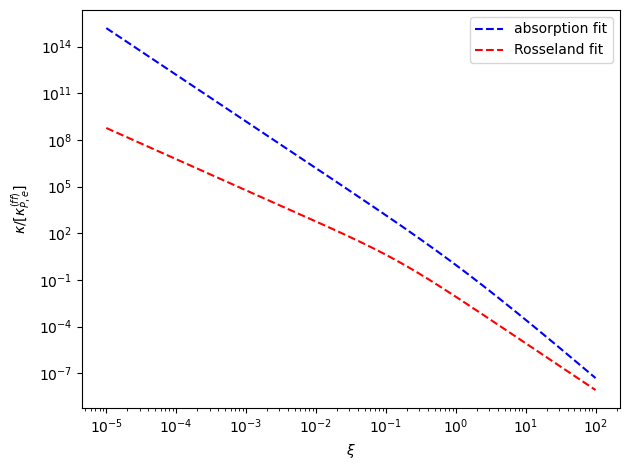

In [19]:
xi_arr = np.logspace(-5, 2, 300)   # match paper's x range

def kPa_ff_fit(xi_arr):
    return xi_arr**(-3) * np.log(1 + 1.6*xi_arr) / (xi_arr * 1.047)

I2 = np.pi**4 / 15
I4 = 4 * np.pi**4 / 15

def kR_ff_fit(xi_arr):
    fR = 1.0 / (432.7 - 106.8*xi_arr**(-3/5) + 43.17*xi_arr**(-4/5) + 57.88/xi_arr)
    return xi_arr**(-3) * (I2/I4) * 14.12 * fR

fig, ax = plt.subplots()
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$\kappa / [\kappa_{P,e}^{(ff)}]$')

ax.plot(xi_arr, kPa_ff_fit(xi_arr), 'b--', label='absorption fit')
ax.plot(xi_arr, kR_ff_fit(xi_arr),  'r--', label='Rosseland fit')
ax.legend()
plt.tight_layout()

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/204573849.py:41: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return integrate.quad(integrand, 1e-6, upper, limit=200)[0]
/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_97581/204573849.py:41: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return integrate.quad(integrand, 1e-6, upper, limit=200)[0]


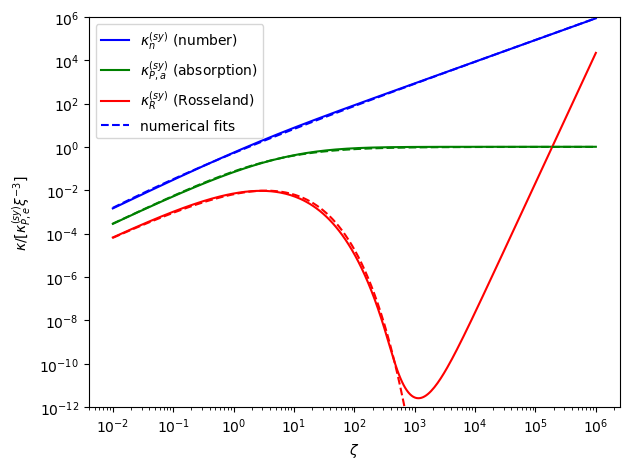

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# --- Setup ---
xi = 1
zeta_arr = np.logspace(-2, 6, 300)

# --- eq. B25: spectral shape function from Mahadevan et al. (1996) ---
def I_prime(xM):
    return (4.0505 / xM**(1/6)) * (1 + 0.40/xM**(1/4) + 0.5316/xM**(1/2)) * np.exp(-1.8899 * xM**(1/3))

# --- eq. B33: integral for Rosseland mean ---
def I6_exact(zeta):
    def integrand(xM):
        u = xM / (2 * zeta)
        if u > 300:
            return 0.0
        return xM**5 / (I_prime(xM) * (2 * np.sinh(u))**2)
    upper = min(50 * zeta, 1e4)
    return integrate.quad(integrand, 1e-6, upper, limit=200)[0]

# --- eq. B34: integral for absorption mean ---
def I7_exact(zeta):
    def integrand(xM):
        u = xM / zeta
        if u > 600:
            return 0.0
        return I_prime(xM) * xM**2 / (np.exp(u) - 1)
    upper = min(50 * zeta, 1e4)
    return integrate.quad(integrand, 1e-6, upper, limit=200)[0]

# --- eq. B35: integral for number mean ---
def I8_exact(zeta):
    def integrand(xM):
        u = xM / zeta
        if u > 600:
            return 0.0
        return I_prime(xM) * xM / (np.exp(u) - 1)
    upper = min(50 * zeta, 1e4)
    return integrate.quad(integrand, 1e-6, upper, limit=200)[0]

# --- constants (eqs. B17, B19, B36) ---
I2 = np.pi**4 / 15
I4 = 4 * np.pi**4 / 15
I9 = 2.404

# --- eqs. B30, B31, B32 (exact, middle lines) ---
ratio_R_exact  = lambda zeta: (xi**-3) * 6.54    * zeta**8  / I6_exact(zeta)
ratio_Pa_exact = lambda zeta: (xi**-3) * 3.88e-2 * zeta**-1 * I7_exact(zeta)
ratio_n_exact  = lambda zeta: (xi**-3) * 1.05e-1 * I8_exact(zeta)

# --- eqs. B30, B31, B32 (fitting formulae, bottom lines) ---
def kR_fit(zeta):
    return 3.24e-2 * zeta**1.31 * np.exp(-1.60 * zeta**0.463)

def kPa_fit(zeta):
    return 1.0 / (1 + 5.444*zeta**(-2/3) + 7.218*zeta**(-4/3))

def kn_fit(zeta):
    return 0.868 * zeta / (1 + 0.589*zeta**(-1/3) + 0.087*zeta**(-2/3))

# --- Plot ---
fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\zeta$')
ax.set_ylabel(r'$\kappa / [\kappa_{P,e}^{(sy)} \xi^{-3}]$')

ax.plot(zeta_arr, [ratio_n_exact(z)  for z in zeta_arr], color='blue',  label=r'$\kappa_n^{(sy)}$ (number)')
ax.plot(zeta_arr, [ratio_Pa_exact(z) for z in zeta_arr], color='green', label=r'$\kappa_{P,a}^{(sy)}$ (absorption)')
ax.plot(zeta_arr, [ratio_R_exact(z)  for z in zeta_arr], color='red',   label=r'$\kappa_R^{(sy)}$ (Rosseland)')

ax.plot(zeta_arr, kn_fit(zeta_arr),  'b--', label='numerical fits')
ax.plot(zeta_arr, kPa_fit(zeta_arr), 'g--')
ax.plot(zeta_arr, kR_fit(zeta_arr),  'r--')

ax.legend()
ax.set_ylim(1e-12, 1e6)
plt.tight_layout()
plt.savefig('figB2.pdf')